In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    destroy, qeye, tensor, basis, thermal_dm, mesolve
)
from scipy.optimize import curve_fit


In [ ]:
# =========================
# 1. Basic model settings
# =========================
# Units: angular frequency (rad / us)
# Example:
#   2*pi*1 MHz  -> 2*pi rad/us
#   time unit   -> us

pi = np.pi

wc = 2 * pi * 7.00      # cavity frequency, GHz-like scaled to /us if you want
wq = 2 * pi * 4.500      # qubit frequency
g  = 2 * pi * 0.10      # qubit-cavity coupling

kappa = 2 * pi * 0.02   # cavity decay rate
gamma_q = 2 * pi * 0.0001  # intrinsic qubit relaxation
gamma_phi = 0.0            # optional pure dephasing

Ncav = 15                  # cavity truncation
tmax = 10 / kappa              # us
nt = 2001
tlist = np.linspace(0.0, tmax, nt)

# scan average thermal photon number
nbar_list = np.linspace(0.0, 0.3, 16)

# fit window: sometimes fitting too early or too late is less stable
fit_tmin = 1.0
fit_tmax = 120.0

chi = g**2/(wc-wq)
print(f'2 chi = {2*chi /(2*pi):.6f} GHz, while kappa = {kappa/(2*pi):.6f} GHz,'
+'\n which need to be close to each other')

2 chi = 0.008000 GHz, while kappa = 0.010000 GHz,
 which need to be close to each other


In [31]:
# =========================
# 2. Operators
# =========================
a = tensor(destroy(Ncav), qeye(2))
adag = a.dag()

sm = tensor(qeye(Ncav), basis(2, 0) * basis(2, 1).dag())   # |g><e|
sp = sm.dag()
sz = tensor(qeye(Ncav), basis(2, 1) * basis(2, 1).dag() - basis(2, 0) * basis(2, 0).dag())

proj_e = tensor(qeye(Ncav), basis(2, 1) * basis(2, 1).dag())

# JC Hamiltonian
H = wc * adag * a + wq * sp * sm + g * (adag * sm + a * sp)

In [32]:
# =========================
# 3. Helper functions
# =========================
def build_c_ops(nth):
    """
    Thermal bath for cavity:
        kappa * (nth + 1) * D[a] + kappa * nth * D[a^\dagger]
    plus optional qubit intrinsic relaxation/dephasing.
    """
    c_ops = []

    # cavity loss into thermal bath
    if kappa * (nth + 1) > 0:
        c_ops.append(np.sqrt(kappa * (nth + 1)) * a)
    if kappa * nth > 0:
        c_ops.append(np.sqrt(kappa * nth) * adag)

    # intrinsic qubit T1
    if gamma_q > 0:
        c_ops.append(np.sqrt(gamma_q) * sm)

    # optional pure dephasing
    # convention depends on definition; here use gamma_phi/2 * D[sz]
    if gamma_phi > 0:
        c_ops.append(np.sqrt(gamma_phi / 2.0) * sz)

    return c_ops


def excited_population_vs_time(nth, qubit_init='g'):
    """
    Initial state:
      cavity: thermal state with average photon number nth
      qubit : |g> or |e>

    Return:
      Pe(t)
    """
    rho_c = thermal_dm(Ncav, nth)

    if qubit_init == 'g':
        rho_q = basis(2, 0) * basis(2, 0).dag()
    elif qubit_init == 'e':
        rho_q = basis(2, 1) * basis(2, 1).dag()
    else:
        raise ValueError("qubit_init must be 'g' or 'e'")

    rho0 = tensor(rho_c, rho_q)
    c_ops = build_c_ops(nth)

    result = mesolve(H, rho0, tlist, c_ops, e_ops=[proj_e])
    Pe = np.real(result.expect[0])
    return Pe


def exp_to_ss(t, Pss, Gamma1, P0):
    """
    P(t) = Pss + (P0 - Pss) * exp(-Gamma1 * t)
    """
    return Pss + (P0 - Pss) * np.exp(-Gamma1 * t)


def fit_rates_from_two_curves(tlist, Pe_g, Pe_e, fit_tmin=0.0, fit_tmax=None):
    """
    Fit the two curves simultaneously:
      from |g>: P_e^g(t) = Pss * (1 - exp(-Gamma1 t))
      from |e>: P_e^e(t) = Pss + (1 - Pss) * exp(-Gamma1 t)

    More generally:
      P(t) = Pss + (P0 - Pss) exp(-Gamma1 t)

    Then:
      Gamma_up   = Pss * Gamma1
      Gamma_down = (1 - Pss) * Gamma1
    """
    if fit_tmax is None:
        fit_tmax = tlist[-1]

    mask = (tlist >= fit_tmin) & (tlist <= fit_tmax)
    tfit = tlist[mask]
    yg = Pe_g[mask]
    ye = Pe_e[mask]

    def combined_model(t_concat, Pss, Gamma1):
        n = len(tfit)
        tg = t_concat[:n]
        te = t_concat[n:]
        y1 = exp_to_ss(tg, Pss, Gamma1, P0=0.0)
        y2 = exp_to_ss(te, Pss, Gamma1, P0=1.0)
        return np.concatenate([y1, y2])

    xdata = np.concatenate([tfit, tfit])
    ydata = np.concatenate([yg, ye])

    # initial guesses
    Pss0 = np.mean(Pe_g[-200:])  # use late-time value from g-init trajectory
    Pss0 = np.clip(Pss0, 1e-6, 1 - 1e-6)
    Gamma10 = 0.01

    bounds = ([0.0, 0.0], [1.0, np.inf])

    popt, pcov = curve_fit(
        combined_model,
        xdata,
        ydata,
        p0=[Pss0, Gamma10],
        bounds=bounds,
        maxfev=20000
    )

    Pss_fit, Gamma1_fit = popt
    Gamma_up = Pss_fit * Gamma1_fit
    Gamma_down = (1.0 - Pss_fit) * Gamma1_fit

    return {
        'Pss': Pss_fit,
        'Gamma1': Gamma1_fit,
        'Gamma_up': Gamma_up,
        'Gamma_down': Gamma_down,
        'pcov': pcov
    }

In [33]:
# =========================
# 4. Run scan over nbar
# =========================
Gamma_up_list = []
Gamma_down_list = []
Gamma_1_list = []
Pss_list = []

example_curves = {}

for nth in nbar_list:
    Pe_g = excited_population_vs_time(nth, qubit_init='g')
    Pe_e = excited_population_vs_time(nth, qubit_init='e')

    fit_res = fit_rates_from_two_curves(
        tlist, Pe_g, Pe_e,
        fit_tmin=fit_tmin,
        fit_tmax=fit_tmax
    )

    Gamma_up_list.append(fit_res['Gamma_up'])
    Gamma_down_list.append(fit_res['Gamma_down'])
    Gamma_1_list.append(fit_res['Gamma1'])
    Pss_list.append(fit_res['Pss'])

    # save one example curve
    if np.isclose(nth, 0.1, atol=1e-12):
        example_curves['nth'] = nth
        example_curves['Pe_g'] = Pe_g
        example_curves['Pe_e'] = Pe_e
        example_curves['fit'] = fit_res

Gamma_up_list = np.array(Gamma_up_list)
Gamma_down_list = np.array(Gamma_down_list)
Gamma_1_list = np.array(Gamma_1_list)
Pss_list = np.array(Pss_list)

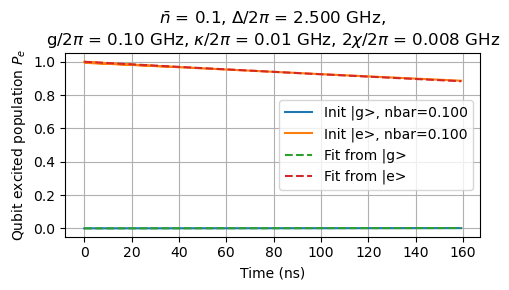

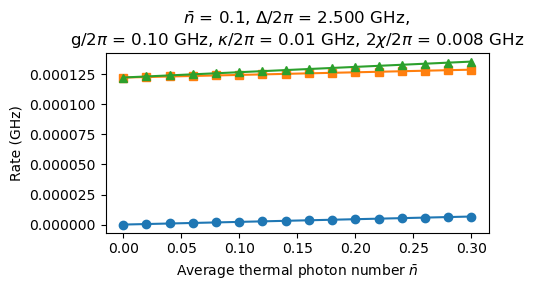

nbar	Gamma_up/2pi	Gamma_down/2pi	Gamma_1/2pi	Pss
0.0000	2.488318e-08	1.222060e-04	1.222309e-04	0.000204
0.0200	4.717534e-07	1.226439e-04	1.231157e-04	0.003832
0.0400	9.185510e-07	1.230816e-04	1.240001e-04	0.007408
0.0600	1.365193e-06	1.235192e-04	1.248843e-04	0.010932
0.0800	1.811703e-06	1.239566e-04	1.257683e-04	0.014405
0.1000	2.258075e-06	1.243939e-04	1.266520e-04	0.017829
0.1200	2.704320e-06	1.248311e-04	1.275354e-04	0.021204
0.1400	3.150432e-06	1.252682e-04	1.284186e-04	0.024533
0.1600	3.596409e-06	1.257051e-04	1.293015e-04	0.027814
0.1800	4.042254e-06	1.261419e-04	1.301842e-04	0.031050
0.2000	4.487969e-06	1.265786e-04	1.310666e-04	0.034242
0.2200	4.933549e-06	1.270151e-04	1.319487e-04	0.037390
0.2400	5.378998e-06	1.274516e-04	1.328306e-04	0.040495
0.2600	5.824317e-06	1.278879e-04	1.337122e-04	0.043559
0.2800	6.269507e-06	1.283241e-04	1.345936e-04	0.046581
0.3000	6.714561e-06	1.287601e-04	1.354747e-04	0.049563


In [61]:
# =========================
# 5. Plot example dynamics at nbar ~ 0.1
# =========================
if 'nth' in example_curves:
    nth = example_curves['nth']
    Pe_g = example_curves['Pe_g']
    Pe_e = example_curves['Pe_e']
    fit_res = example_curves['fit']

    Pss = fit_res['Pss']
    G1 = fit_res['Gamma1']

    fit_g = exp_to_ss(tlist, Pss, G1, 0.0)
    fit_e = exp_to_ss(tlist, Pss, G1, 1.0)

    plt.figure(figsize=(5, 3))
    plt.plot(tlist, Pe_g, label=f'Init |g>, nbar={nth:.3f}')
    plt.plot(tlist, Pe_e, label=f'Init |e>, nbar={nth:.3f}')
    plt.plot(tlist, fit_g, '--', label='Fit from |g>')
    plt.plot(tlist, fit_e, '--', label='Fit from |e>')
    plt.xlabel('Time (ns)')
    plt.ylabel('Qubit excited population $P_e$')
    plt.title(fr'$\bar{{n}}$ = 0.1, $\Delta/2\pi$ = {(wc-wq)/2/pi:.3f} GHz, '+'\n'+ 
    fr'g/2$\pi$ = {g/2/pi:.2f} GHz, $\kappa$/2$\pi$ = {kappa/2/pi:.2f} GHz, 2$\chi$/2$\pi$ = {2*chi /(2*pi):.3f} GHz')
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()


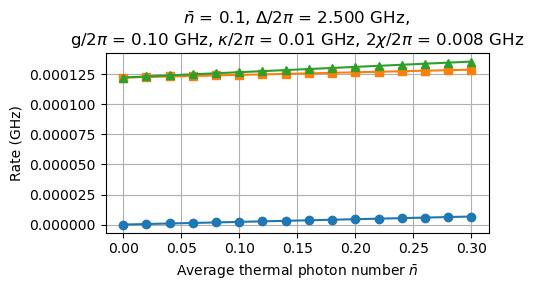

nbar	Gamma_up/2pi	Gamma_down/2pi	Gamma_1/2pi	Pss
0.0000	2.488318e-08	1.222060e-04	1.222309e-04	0.000204
0.0200	4.717534e-07	1.226439e-04	1.231157e-04	0.003832
0.0400	9.185510e-07	1.230816e-04	1.240001e-04	0.007408
0.0600	1.365193e-06	1.235192e-04	1.248843e-04	0.010932
0.0800	1.811703e-06	1.239566e-04	1.257683e-04	0.014405
0.1000	2.258075e-06	1.243939e-04	1.266520e-04	0.017829
0.1200	2.704320e-06	1.248311e-04	1.275354e-04	0.021204
0.1400	3.150432e-06	1.252682e-04	1.284186e-04	0.024533
0.1600	3.596409e-06	1.257051e-04	1.293015e-04	0.027814
0.1800	4.042254e-06	1.261419e-04	1.301842e-04	0.031050
0.2000	4.487969e-06	1.265786e-04	1.310666e-04	0.034242
0.2200	4.933549e-06	1.270151e-04	1.319487e-04	0.037390
0.2400	5.378998e-06	1.274516e-04	1.328306e-04	0.040495
0.2600	5.824317e-06	1.278879e-04	1.337122e-04	0.043559
0.2800	6.269507e-06	1.283241e-04	1.345936e-04	0.046581
0.3000	6.714561e-06	1.287601e-04	1.354747e-04	0.049563


In [62]:

# =========================
# 6. Plot rates vs average thermal photon number
# =========================
plt.figure(figsize=(5, 3))
plt.plot(nbar_list, Gamma_up_list / (2 * pi), 'o-', label=r'$\Gamma_\uparrow / 2\pi$')
plt.plot(nbar_list, Gamma_down_list / (2 * pi), 's-', label=r'$\Gamma_\downarrow / 2\pi$')
plt.plot(nbar_list, Gamma_1_list / (2 * pi), '^-', label=r'$\Gamma_1 / 2\pi$')
plt.xlabel('Average thermal photon number $\\bar{n}$')
plt.ylabel('Rate (GHz)')
# plt.title('Transition rates vs average thermal photon number')
plt.title(fr'$\bar{{n}}$ = 0.1, $\Delta/2\pi$ = {(wc-wq)/2/pi:.3f} GHz, '+'\n'+ 
fr'g/2$\pi$ = {g/2/pi:.2f} GHz, $\kappa$/2$\pi$ = {kappa/2/pi:.2f} GHz, 2$\chi$/2$\pi$ = {2*chi /(2*pi):.3f} GHz')
plt.grid()
plt.tight_layout()
plt.show()

# =========================
# 7. Print numerical results
# =========================
print("nbar\tGamma_up/2pi\tGamma_down/2pi\tGamma_1/2pi\tPss")
for nth, gu, gd, g1, pss in zip(nbar_list, Gamma_up_list, Gamma_down_list, Gamma_1_list, Pss_list):
    print(f"{nth:.4f}\t{gu/(2*pi):.6e}\t{gd/(2*pi):.6e}\t{g1/(2*pi):.6e}\t{pss:.6f}")